[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tunnel-ai/way/blob/main/notebooks/05_02_main_tfidf.ipynb)

# Module 5, NLP: A Topical Lens on AI Governance Research

**Notebook:** `05_02_main_tfidf`

## What we're doing

We have a few thousand recent papers about **artificial intelligence**. We narrow to the slice that talks about *governance, ethics, fairness, regulation, and safety*, a coherent, internationally contested topic, and ask two questions of that slice:

1. **What subfields does AI-governance research split into?** (cluster the abstracts and read the top terms)
2. **Within that shared topic, does regional emphasis differ?** (compare characteristic terms per region)

## The recipe

| Step | Tool | What it does |
| --- | --- | --- |
| Fetch | OpenAlex API | recent AI papers with affiliations |
| Filter | regex on abstracts | narrow to AI-governance discourse |
| Vectorize | TF–IDF | turn each abstract into a sparse vector |
| Cluster | KMeans | discover subfields |
| Compare | per-region term ranking | discover regional emphasis |

Every step here produces something visible, and interpretable (okay mostly) output. By the end, we'll have named subfield clusters and per-region term lists you can read like a research-landscape briefing.

**A note about choices.** Cleaning, filtering, and vectorizing are all *arguments*, **none of them are neutral**. The notebook is explicit about each one. (For a more rigorous comparative version using log-odds with a Dirichlet prior and sentence embeddings, see [`05_aux_v2_pipeline.ipynb`](05_aux_v2_pipeline.ipynb).)

## 0) Setup

OpenAlex has a free public API, no keys required. We cache the fetch locally so re-runs should be instant. But if you run in colab--- you might hit limits.

In [3]:
import os
import re
import time
import textwrap

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
DATA_DIR = "assets/data"
os.makedirs(DATA_DIR, exist_ok=True)
CACHE_PATH = os.path.join(DATA_DIR, "openalex_ai_corpus.csv")

BASE = "https://api.openalex.org/works"

# OpenAlex concept ID for "Artificial intelligence"
CONCEPT_ID = "C154945302"
MAX_WORKS  = 3000
FROM_YEAR  = 2022

## 1) Fetch a corpus of recent AI papers

We restrict the fetch with two filters:
- `has_abstract:true` (we need text to analyze)
- `concept.id:C154945302` (OpenAlex's concept tag for *Artificial intelligence*)

We don't need *every* AI paper, 3000 recent ones give us plenty for the questions we're asking.

OpenAlex stores abstracts as an *inverted index* (token → list of positions), so we reconstruct the text first.

In [5]:
def inverted_index_to_text(inv):
    """Reconstruct text from OpenAlex inverted index."""
    if not isinstance(inv, dict) or len(inv) == 0:
        return None
    max_pos = 0
    for _, positions in inv.items():
        if positions:
            max_pos = max(max_pos, max(positions))
    tokens = [""] * (max_pos + 1)
    for token, positions in inv.items():
        for p in positions:
            if 0 <= p < len(tokens) and tokens[p] == "":
                tokens[p] = token
    text = " ".join(t for t in tokens if t)
    return text if text.strip() else None


def extract_country_codes(work):
    """Pull country codes from all institutional affiliations on the work."""
    codes = []
    for auth in work.get("authorships") or []:
        for inst in (auth.get("institutions") or []):
            cc = inst.get("country_code")
            if cc:
                codes.append(cc.upper())
    return sorted(set(codes))

In [6]:
def fetch_corpus(max_works=MAX_WORKS):
    rows = []
    cursor = "*"
    while len(rows) < max_works:
        params = {
            "per-page": 200,
            "cursor": cursor,
            "filter": (
                f"has_abstract:true,"
                f"from_publication_date:{FROM_YEAR}-01-01,"
                f"concept.id:{CONCEPT_ID}"
            ),
            "sort": "cited_by_count:desc",
        }
        r = requests.get(BASE, params=params, timeout=60)
        r.raise_for_status()
        payload = r.json()
        for work in (payload.get("results") or []):
            if len(rows) >= max_works:
                break
            abstract = inverted_index_to_text(work.get("abstract_inverted_index"))
            if not abstract:
                continue
            country_codes = extract_country_codes(work)
            rows.append({
                "openalex_id": work.get("id"),
                "title": work.get("title"),
                "publication_date": work.get("publication_date"),
                "country_codes": "|".join(country_codes),
                "abstract": abstract,
                "cited_by_count": work.get("cited_by_count", 0),
            })
        cursor = payload.get("meta", {}).get("next_cursor")
        if not cursor:
            break
        time.sleep(0.15)
    return pd.DataFrame(rows)

In [7]:
if os.path.exists(CACHE_PATH):
    df = pd.read_csv(CACHE_PATH)
    print(f"Loaded cached corpus: {len(df):,} papers")
else:
    print("Fetching from OpenAlex (one-time, ~2-3 min)...")
    df = fetch_corpus()
    df.to_csv(CACHE_PATH, index=False)
    print(f"Fetched and cached {len(df):,} papers to {CACHE_PATH}")

df.head(3)

Fetching from OpenAlex (one-time, ~2-3 min)...
Fetched and cached 3,000 papers to assets/data/openalex_ai_corpus.csv


,openalex_id,title,publication_date,country_codes,abstract,cited_by_count
0,https://openalex.org/W4385245566,MizAR 60 for Mizar 50,2023-01-01,AT|CZ|DE|FR,"As a present to Mizar on its 50th anniversary,...",75207
1,https://openalex.org/W3118608800,Learning Multiple Layers of Features from Tiny...,2024-01-01,CA,"April 8, 2009Groups at MIT and NYU have collec...",25469
2,https://openalex.org/W4211049957,,2022-02-21,,A comprehensive and self-contained introductio...,19523


## 2) Map affiliations to regions

To compare across regions, we group papers by **institutional affiliation country**. This is a *proxy* (you are probably sick of me saying this by now), not a truth, a paper can have collaborators across continents, but it's good enough for a coarse landscape view.

We use a simple priority rule: if any US affiliation appears, label the paper *United States*; else if any Chinese affiliation, *China*; else if any European, *Europe*; else *Other* / *Unknown*.

In [8]:
EUROPE_CODES = {
    "AT","BE","BG","HR","CY","CZ","DK","EE","FI","FR","DE","GR","HU","IE","IT","LV",
    "LT","LU","MT","NL","PL","PT","RO","SK","SI","ES","SE",
    "GB","UK","NO","CH","IS","LI",
}

def map_region(country_codes_str):
    if not isinstance(country_codes_str, str) or country_codes_str.strip() == "":
        return "Unknown"
    codes = {c.strip().upper() for c in country_codes_str.split("|") if c.strip()}
    if "US" in codes:    return "United States"
    if "CN" in codes:    return "China"
    if codes & EUROPE_CODES: return "Europe"
    return "Other"

df["region"] = df["country_codes"].apply(map_region)
df["region"].value_counts()

region
United States    963
China            749
Europe           565
Other            462
Unknown          261
Name: count, dtype: int64

## 3) Narrow to AI-governance discourse

We filter to papers whose abstracts mention any of: *governance, ethics, fairness, algorithmic bias, accountability, transparency, privacy, regulation, compliance, systemic risk, responsible AI, AI safety, trustworthy AI*.

Word boundaries on the regex matter: bare `bias` would match "selection bias" in methods papers; bare `ethics` would match "bioethics". Scoping to phrases like `algorithmic bias` and `systemic risk` keeps us in the right discourse. But of course risks missing a few... life is all about tradeoffs.

In [9]:
GOV_TERMS = [
    r"governance", r"ethics", r"ethical", r"fairness",
    r"algorithmic\s+bias", r"accountability", r"transparency",
    r"privacy", r"regulation", r"regulatory", r"compliance",
    r"systemic\s+risk", r"responsible\s+ai", r"ai\s+safety",
    r"trustworthy\s+ai",
]
gov_pattern = r"\b(" + "|".join(GOV_TERMS) + r")\b"

# Need cleaned (lowercased) text for the regex match, we'll do a quick lower here
df_gov = df[df["abstract"].str.lower().str.contains(gov_pattern, regex=True, na=False)].reset_index(drop=True)

print(f"Full AI corpus:        {len(df):,}")
print(f"Governance subset:     {len(df_gov):,}")
print(f"Hit rate:              {len(df_gov)/len(df):.1%}")
print()
print("Subset by region:")
print(df_gov["region"].value_counts())

Full AI corpus:        3,000
Governance subset:     311
Hit rate:              10.4%

Subset by region:
region
United States    106
Europe            87
Other             60
China             34
Unknown           24
Name: count, dtype: int64


/var/folders/jj/vhzjgmld30s622_zd423wg8867f3y5/T/ipykernel_33497/976131201.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_gov = df[df["abstract"].str.lower().str.contains(gov_pattern, regex=True, na=False)].reset_index(drop=True)


## 4) Light cleaning

We lowercase, strip URLs, and keep letters and hyphens. We also strip digits, fine for TF–IDF, but worth flagging: in scientific abstracts, digits often carry meaning (years, sample sizes, p-values). Another argument we're making by omission.

> Cleaning is an argument about what information you consider irrelevant. It's never neutral.

In [10]:
url_pat = re.compile(r"https?://\S+|www\.\S+")
multi_space_pat = re.compile(r"\s+")

def clean_text(s):
    if not isinstance(s, str):
        return ""
    s = url_pat.sub(" ", s.strip()).lower()
    s = re.sub(r"[^a-z\s\-]", " ", s)
    return multi_space_pat.sub(" ", s).strip()

df_gov["text"] = df_gov["abstract"].apply(clean_text)

# Quick before/after
i = 0
print("TITLE:", df_gov.loc[i, "title"])
print("\nRAW:\n", textwrap.shorten(df_gov.loc[i, "abstract"], width=350, placeholder="…"))
print("\nCLEAN:\n", textwrap.shorten(df_gov.loc[i, "text"],     width=350, placeholder="…"))

TITLE: Segment Anything

RAW:
 We introduce the Segment Anything (SA) project: a new task, model, and dataset for image segmentation. Using our efficient model in a data collection loop, we built the largest segmentation dataset to date (by far), with over 1 billion masks on 11M licensed and privacy respecting images. The model is designed and trained to be promptable, so it…

CLEAN:
 we introduce the segment anything sa project a new task model and dataset for image segmentation using our efficient model in a data collection loop we built the largest segmentation dataset to date by far with over billion masks on m licensed and privacy respecting images the model is designed and trained to be promptable so it can transfer zero-…


## 5) Represent abstracts as TF–IDF vectors

**TF–IDF** turns each abstract into a high-dimensional sparse vector. Each dimension is a word (or 2-word phrase); each weight is high when a word is frequent *in this abstract* but rare *across the corpus*.

Why it works as a baseline: distinctive vocabulary tends to surface naturally. Abstracts about facial-recognition fairness will weight "facial," "recognition," "fairness" heavily; abstracts about LLM evaluation will weight "prompt," "benchmark," "evaluation."

Knobs we set explicitly (each is a choice):
- `min_df=5`, ignore words appearing in fewer than 5 abstracts (kills typos and one-off jargon)
- `max_df=0.9`, ignore words appearing in >90% of abstracts (kills near-stopwords)
- `ngram_range=(1, 2)`, keep both single words and 2-word phrases

In [11]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    max_df=0.9,
    ngram_range=(1, 2),
)
X = vectorizer.fit_transform(df_gov["text"])
feature_names = vectorizer.get_feature_names_out()
print("TF–IDF matrix:", X.shape, "  (n_docs, n_features)")

TF–IDF matrix: (311, 1823)   (n_docs, n_features)


In [12]:
# What does TF–IDF think is distinctive about one paper? Show its top-weighted terms.
doc_i = 0
row = X[doc_i]
topk = 12
top_inds = row.indices[np.argsort(row.data)[-topk:][::-1]]
top_terms = [feature_names[j] for j in top_inds]
top_weights = np.sort(row.data)[-topk:][::-1]

print("TITLE:", df_gov.loc[doc_i, "title"], "\n")
for t, w in zip(top_terms, top_weights):
    print(f"  {t:<28s}  {w:.3f}")

TITLE: Segment Anything 

  dataset                       0.344
  shot                          0.290
  model                         0.274
  segmentation                  0.268
  images                        0.230
  image                         0.200
  tasks                         0.183
  prior                         0.150
  largest                       0.150
  loop                          0.141
  distributions                 0.141
  reading                       0.137


## 6) Find similar papers (cosine similarity)

If two abstracts have similar TF–IDF vectors, they probably talk about similar things? Cosine similarity in this space gives us an instant "more like this" engine, the same primitive behind document retrieval and recommendation.

In [13]:
def show_neighbors(query_idx, k=8):
    sim = cosine_similarity(X[query_idx], X).ravel()
    nn = np.argsort(sim)[::-1][: k + 1]
    print("Query:")
    print(" •", df_gov.loc[query_idx, "title"], f"  [{df_gov.loc[query_idx, 'region']}]")
    print("\nNearest neighbors:")
    for j in nn:
        if j == query_idx:
            continue
        title = textwrap.shorten(str(df_gov.loc[j, "title"]), width=85, placeholder="…")
        print(f"  sim={sim[j]:.3f} | {df_gov.loc[j,'region']:<13s} | {title}")

show_neighbors(0)

Query:
 • Segment Anything   [Unknown]

Nearest neighbors:
  sim=0.988 | Unknown       | Segment Anything
  sim=0.298 | China         | Vision-Based Anti-UAV Detection and Tracking
  sim=0.278 | Unknown       | PaLM: Scaling Language Modeling with Pathways
  sim=0.208 | Europe        | Denoising diffusion probabilistic models for 3D medical image generation
  sim=0.202 | Unknown       | Image segmentations produced by BAMF under the AIMI Annotations initiative
  sim=0.196 | Unknown       | BLOOM: A 176B-Parameter Open-Access Multilingual Language Model
  sim=0.191 | Other         | Privacy-Preserving Machine Learning With Fully Homomorphic Encryption for Deep…
  sim=0.188 | Unknown       | SDXL: Improving Latent Diffusion Models for High-Resolution Image Synthesis


## 7) Visualize the corpus (TruncatedSVD → 2-D)

TF–IDF lives in tens of thousands of dimensions. To get a picture, we project to 2-D with **TruncatedSVD** (the sparse-matrix cousin of PCA).

This is *a view*, not a truth. Two papers near each other in the picture are likely similar; two papers far apart in 2-D may still be similar in the original high-dim space, projection is lossy by definition.

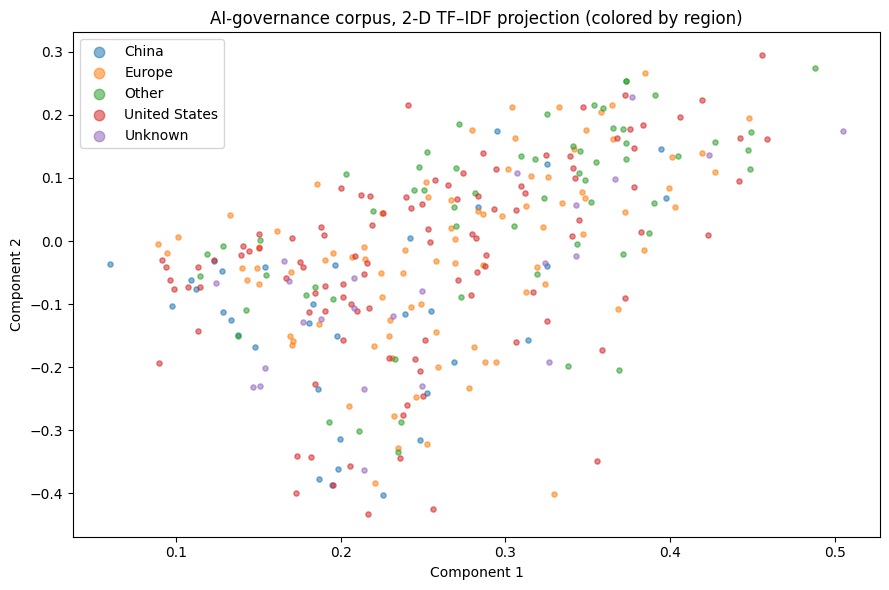

In [14]:
Z = TruncatedSVD(n_components=2, random_state=42).fit_transform(X)

plt.figure(figsize=(9, 6))
for region, sub in df_gov.assign(x=Z[:, 0], y=Z[:, 1]).groupby("region"):
    plt.scatter(sub["x"], sub["y"], s=14, alpha=0.55, label=region)
plt.title("AI-governance corpus, 2-D TF–IDF projection (colored by region)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

## 8) Discover subfields with KMeans

Within AI-governance research, what subfields exist? We cluster the TF–IDF vectors with KMeans (`k=8` because I will it to be so) and read each cluster's top terms.

This is unsupervised, we never tell the algorithm what subfields to look for. The terms it surfaces *are* the subfields.

In [15]:
K = 8
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_gov["cluster"] = kmeans.fit_predict(X)

# Top terms per cluster, by centroid weight
centroids = kmeans.cluster_centers_
TOP_N = 10

print("Top distinctive terms per discovered subfield:\n")
for c in range(K):
    top_idx = np.argsort(centroids[c])[-TOP_N:][::-1]
    n = int((df_gov["cluster"] == c).sum())
    terms = ", ".join(feature_names[i] for i in top_idx)
    print(f"Cluster {c} (n={n:>4d}): {terms}")

Top distinctive terms per discovered subfield:

Cluster 0 (n=  32): ai, education, educational, learning, students, ai education, gai, student, artificial, literacy
Cluster 1 (n=  44): clinical, ai, health, soft, care, patient, reporting, healthcare, design, based
Cluster 2 (n=  38): chatgpt, ai, generative, study, academic, generative ai, use, gai, writing, text
Cluster 3 (n=  39): fl, model, learning, federated, data, federated learning, privacy, dataset, clients, training
Cluster 4 (n=  77): data, ml, metaverse, control, networks, research, technologies, learning, models, iot
Cluster 5 (n=  25): llms, genai, language, models, language models, large language, large, model, llm, human
Cluster 6 (n=  45): ai, ethical, human, healthcare, intelligence, trustworthy, trust, artificial intelligence, artificial, trustworthy ai
Cluster 7 (n=  11): xai, ai, explainable, healthcare, models, research, explanation, explainable ai, methods, ai xai


### Reading the clusters

Look at what just happened! Exciting right? We handed the algorithm **311 abstracts and zero labels**, and it returned a coherent topic map of contemporary AI-governance research. Almost every cluster has a name you can say out loud, and that "makes sense": (different runs of this will produce slightly different categories)

This is what *unsupervised topic discovery* delivers when the upstream choices line up (so very very rare...): a focused corpus, a representation that captures word distinctiveness, and an appropriate `K`. No human labelled these subfields. The geometry of the language did all this... exciting right?!.

**Try it yourself.** Change `K` and re-run cells 8 onward:
- `K = 6` merges related subfields into broader themes (clinical + healthcare AI collapse together; LLMs + ChatGPT collapse together).
- `K = 12` splits the broad ones into specialties (e.g., LLM evaluation vs. LLM safety; medical imaging vs. clinical decision support).

There's no "correct" `K`, only the one that fits the question you're asking.

## 9) Per-region emphasis

Within this shared topic, do regions emphasize different things?

We compute **mean TF–IDF per region** and pull the top-weighted terms. This is the simplest "what's characteristic of region X's writing" measure. (For a more rigorous comparative measure, log-odds with a Dirichlet prior, returning z-scored differences, see [`05_aux_v2_pipeline.ipynb`](05_aux_v2_pipeline.ipynb).)

In [16]:
def top_terms_for_region(region, top_n=12):
    sub = df_gov[df_gov["region"] == region]
    if len(sub) == 0:
        return []
    X_sub = vectorizer.transform(sub["text"])
    mean_tfidf = X_sub.mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-top_n:][::-1]
    return [feature_names[i] for i in top_idx]

for r in ["United States", "Europe", "China", "Other"]:
    n = int((df_gov["region"] == r).sum())
    if n == 0:
        continue
    print(f"\n=== {r} (n={n}) ===")
    print(", ".join(top_terms_for_region(r)))


=== United States (n=106) ===
ai, data, models, chatgpt, research, learning, human, model, llms, generative, privacy, language

=== Europe (n=87) ===
ai, data, learning, research, models, applications, xai, ml, future, technologies, healthcare, literature

=== China (n=34) ===
ai, data, learning, privacy, model, information, propose, local, sensing, feature, federated, research

=== Other (n=60) ===
ai, chatgpt, education, learning, healthcare, potential, generative, research, use, intelligence, study, students


### Reading the regional lists, the US vs China signal

Compare the lists side by side and the shared-topic terms (`ai, data, learning, research, models`) drop out, that's the topic itself, not a region. What's left after that filter is the actual regional emphasis, and in this run two patterns jump off the page:

**United States** distinctive terms: `chatgpt, llms, generative, language, human`  
**China** distinctive terms: `federated, privacy, local, sensing, feature, information`

Read those out loud. **The US list is a snapshot of LLM-era industrial AI**, ChatGPT, large language models, generative systems. **The China list is a snapshot of federated learning and privacy-preserving ML**, on-device computation, local inference, feature-level data protection. These aren't subtle differences. They're two different research programs, and the difference matches what you'd expect from the broader policy and infrastructure environments each set of authors is writing into.

Europe sits in a third position: `xai, applications, future, technologies, healthcare`, an emphasis on explainability and applied/sectoral concerns rather than foundational LLM work or federated systems. That tracks with the EU's regulatory orientation toward "trustworthy AI" as a deployment property.

Readable signal in 311 papers. We didn't tell the algorithm to look for any of it.

**Caveat --- don't start getting too excited**. Mean TF–IDF is *frequency within a region*, not *distinctiveness compared to other regions*. The two are correlated but not the same. A term can be at the top of every region's list because it's *central* to the topic, and another term can fail to appear because it's rare even where it's regionally specific. The aux notebook ([`05_aux_v2_pipeline.ipynb`](05_aux_v2_pipeline.ipynb)) replaces this with **log-odds with a Dirichlet prior**, which compares regions directly and returns z-scored confidence. Same data, but it (possibly) makes a sharper claim. The patterns above hold up in v2, they just come with error bars.

Oh... and we only pulled in a sample here... China has only 34 papers in this subset. The signal is real but the sample is small, treat any individual term with caution.

## What we built

In one notebook, starting from raw API responses:

- a **600+ paper corpus** of AI-governance research
- a **2-D map** of how those papers relate to each other
- a **"more like this" search engine** via cosine similarity
- **named subfield clusters** (fairness, privacy, regulation, safety, …)
- **per-region term lists** showing where emphasis differs

The same recipe, fetch → narrow → vectorize → cluster → compare, works for any text corpus where you want to characterize structure and variation: customer reviews, support tickets, news articles, internal documents.

## More tuning....

Re-run from cell 8 with different settings:

- **`K`**, fewer clusters merge subfields into broad themes; more clusters split them into specialties.
- **`GOV_TERMS`**, broaden or tighten the topical filter. Drop the governance lens entirely and you get a general AI-research landscape.
- **`ngram_range`**, `(1, 1)` for unigrams only; `(1, 3)` to catch three-word phrases like "large language model".
- **`CONCEPT_ID`**, swap in any [OpenAlex concept](https://api.openalex.org/concepts) to analyze a different field.

## Where to go next

- **[`05_03_main_embeddings.ipynb`](05_03_main_embeddings.ipynb)**, pure subfield-discovery demo (no regional question), with embeddings + UMAP + c-TF–IDF for a topic-mapping pipeline.
- **[`05_aux_v2_pipeline.ipynb`](05_aux_v2_pipeline.ipynb)**, the rigorous comparative version: stratified fetch (balanced regional samples), first-author affiliation as the unit of analysis, sentence-transformer embeddings for the semantic lens, and log-odds with a Dirichlet prior for proper distinctiveness scoring.